In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from astropy.table import Table 
from scipy.optimize import curve_fit

# Task 5 (Hudson)

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erf
from astropy.table import Table 
from scipy.optimize import curve_fit
from scipy.stats import ttest_ind

plt.rcParams['font.family'] = 'Times New Roman'
plt.rc('font', size = 12)

### Selecting Part of Cleaned Data without Transit 

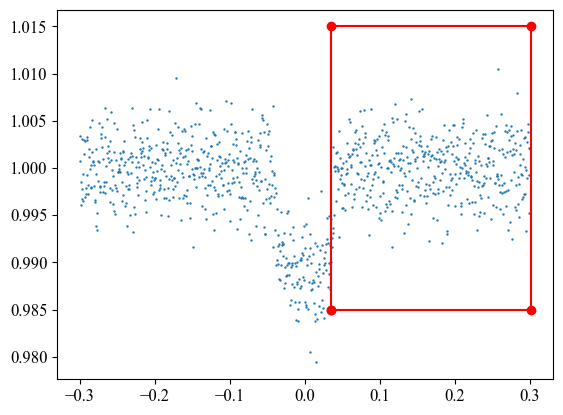

In [7]:
# creating a polygon
x_poly = [0.5*duration, 0.301, 0.301,0.5*duration, 0.5*duration]
y_poly = [0.985, 0.985, 1.015, 1.015, 0.985]
plt.scatter(x_data,clean_y, s=0.5)
plt.plot(x_poly, y_poly, '-o', c='r')

1000


Text(0, 0.5, 'Flux')

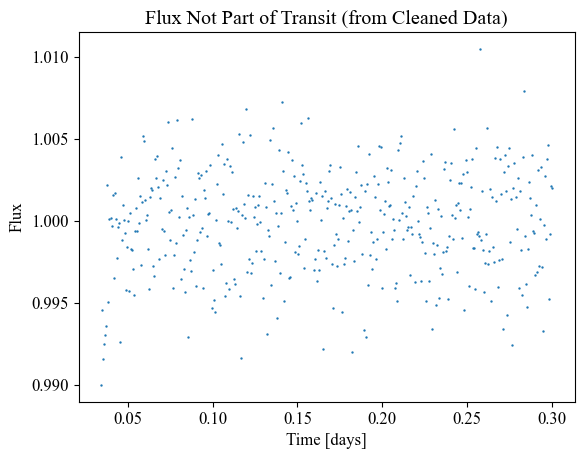

In [8]:
import matplotlib.patches as patches

coords = np.column_stack((x_poly,y_poly))

poly = patches.Polygon(coords)

point_coords = np.column_stack((x_data, clean_y))

is_inpoly = poly.contains_points(point_coords)
#print(is_inpoly)
print(len(is_inpoly))

plt.scatter(x_data[is_inpoly],clean_y[is_inpoly], s=0.5)
plt.title('Flux Not Part of Transit (from Cleaned Data)')
plt.xlabel('Time [days]')
plt.ylabel('Flux')

### Visualizing the Gaussian Distribution of the Cleaned Data

Average flux/brightness observed: 0.9998789903416598
Standard deviation for the flux: 0.030000000000000006


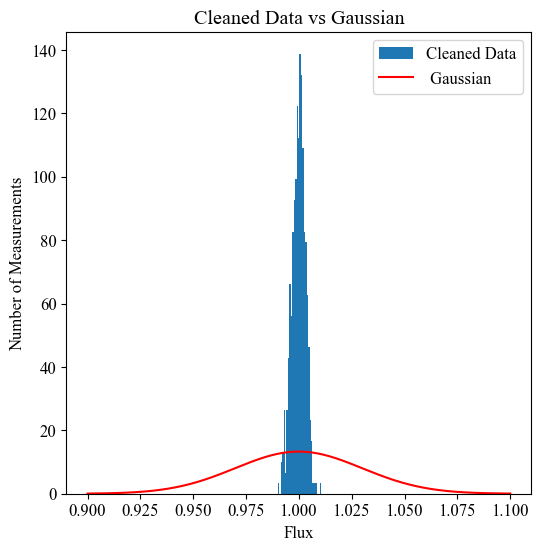

In [9]:
# finding the mean and standard deviation from the cleaned data in polygon
mu = np.mean(clean_y[is_inpoly])
# use sigma after error propogation (task 4)
std = errorprop

print(f'Average flux/brightness observed: {mu}')
print(f'Standard deviation for the flux: {std}')


# creating a function to define a Gaussian 
def gaussian(x, mu, sigma):
    norm = 1/(np.sqrt(2*np.pi*sigma**2)) 

    exponential = np.exp((-1*(x -mu)**2/(2*sigma**2)))

    return norm*exponential

# Plotting the cleaned data as a histogram vs its Gaussian 
# I used plt.scatter rather than plt.plot b/c it represented the Gaussian shape better 
plt.figure(figsize = (6,6))
t = plt.hist(clean_y[is_inpoly], bins = 30, label = 'Cleaned Data', density=True)

xtest = np.linspace(0.9, 1.1, 1000)

plt.plot(xtest, gaussian(xtest, mu, std), c='r', label = ' Gaussian')
plt.xlabel('Flux')
plt.ylabel('Number of Measurements')
plt.title('Cleaned Data vs Gaussian')
plt.legend()
plt.show()


### Creating the Outlier

In [10]:
# creating an outlier with a flux 10% brighter than the mean
outlier = mu*1.1
print(f'Flux of outlier: {outlier}')

# calculating n-sigma of a solar flare 10% brighter than the mean from the cleaned up data 
N_sigma = np.abs((outlier-mu)/std)
print(f'The outlier is a {N_sigma:4.3}-sigma event')


Flux of outlier: 1.0998668893758259
The outlier is a 3.33-sigma event


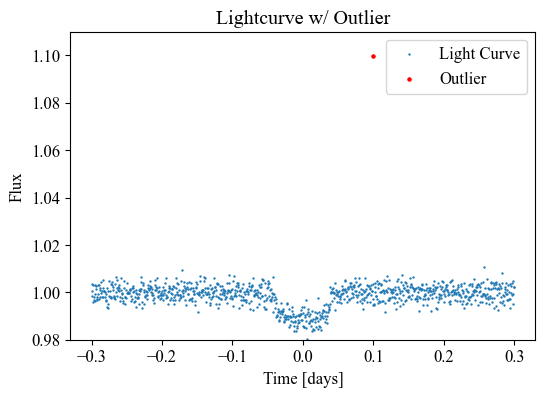

In [12]:
# assigning an arbitrary time (x-value) for the outlier NOT during transit
x_outlier = 0.1

# adding the outlier to the light curve (from Task 2) 
plt.figure(figsize = (6,4))
plt.scatter(x_data,clean_y, s=0.5, label = 'Light Curve')
plt.scatter(x_outlier, outlier, c='r', s = 5, label = 'Outlier')
plt.ylim(0.98, 1.11)
plt.xlabel('Time [days]')
plt.ylabel('Flux')
plt.title('Lightcurve w/ Outlier')
plt.legend()
plt.show()

### Calculating the Statistical Significance of the Outlier 

In [13]:

def solar_flare_prob(x, mu, std):
    '''
    inputs:
        x: solar flare magnitude 
        mu: expected mean from clean data 
        std: expected standard deviation of the Gaussian
    '''
  
    z = np.abs((x-mu)/std)

    prob_upper = 0.5*(1.0 + erf(z/np.sqrt(2)))
    prob_lower = 0.5*(1.0 + erf(-1*z/np.sqrt(2)))

    prob_inside = (prob_upper - prob_lower)

    prob_outside = 1.0 - prob_inside

    return prob_outside 



In [14]:
# declaring probability of outlier 
prob = solar_flare_prob(outlier, mu, std)
print(prob)

print(f'The probability of a solar flare of flux {outlier} is {prob*100:5.3}%.')

0.0008593657075461891
The probability of a solar flare of flux 1.0998668893758259 is 0.0859%.


In [15]:
def chauvenet_criterion(clean_data, outlier):
    '''
    inputs:
        clean_data: array containing the original cleaned-up data set
        outlier: float, 10% brighter outlier along lightcurve where the transit isn't taking place

    returns: 
        keep: boolean, True if we can reject the null hypothesis, False if we can't reject the null hypothesis
    '''
    mu_prior = np.mean(clean_data)
    std_prior = np.std(clean_data)
    outlier_prob = solar_flare_prob(N_sigma, mu_prior, std_prior)

    N = len(clean_data) + 1
    product = N*outlier_prob

    # represents Chauvenet's Criterion 
    # if True, we CAN reject the null hypothesis
    if product < 0.5 and outlier_prob < 1/(2*N):
        reject = True
        return reject
    # if False, CANNOT reject the null hypothesis 
    else:
        reject = False
        return reject

In [16]:
chauvenet = chauvenet_criterion(clean_y[is_inpoly], outlier)
print(f'We can reject the null hypotheis: {chauvenet}')

We can reject the null hypotheis: True
